In [9]:
import pandas as pd
import numpy as np

import plotly.express as px
import plotly.graph_objects as go

from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
X, y = make_regression(n_samples = 100, n_features = 2, n_informative = 2, n_targets = 1, noise = 50)

In [4]:
df = pd.DataFrame({'Feature 1' : X[:, 0], 'Feature 2' : X[:, 1], 'Target' : y})

In [5]:
df.head()

,Feature 1,Feature 2,Target
0,1.661202,0.753879,174.204417
1,-0.446739,0.728391,-61.245583
2,0.345358,0.644847,102.637408
3,-1.042481,0.319119,-66.443911
4,0.014682,0.118542,-88.416921


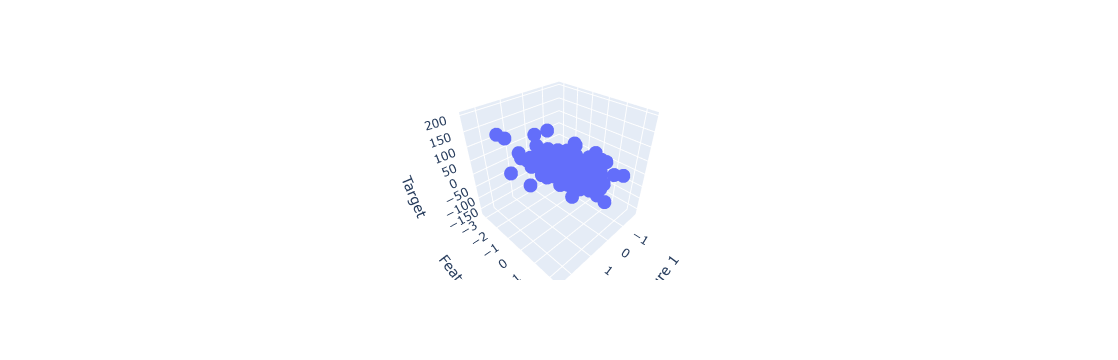

In [8]:
fig = px.scatter_3d(df, x = 'Feature 1', y = 'Feature 2', z = 'Target')

fig.show()

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [11]:
lr = LinearRegression()

lr.fit(X_train, y_train)

LinearRegression()

In [12]:
y_pred = lr.predict(X_test)

In [14]:
print("MAE", mean_absolute_error(y_pred, y_test))
print("MSE", mean_squared_error(y_pred, y_test))
print("R2 score", r2_score(y_pred, y_test))

MAE 41.4934769758746
MSE 2628.287352133686
R2 score 0.40485903519154576


In [22]:
x = np.linspace(-5, 5, 10)
y = np.linspace(-5, 5, 10)

xGrid, yGrid = np.meshgrid(x, y)

final = np.vstack((xGrid.ravel().reshape(1,100), yGrid.ravel().reshape(1,100))).T

z_final = lr.predict(final).reshape(10,10)

z = z_final

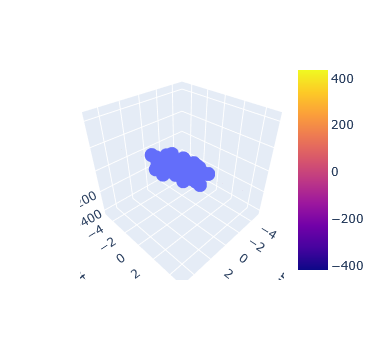

In [24]:
fig = px.scatter_3d(df , x = 'Feature 1', y = 'Feature 2', z = 'Target')
fig.add_trace(go.Surface(x = x, y = y, z = z))

fig.show()

In [26]:
lr.coef_

array([68.07775864, 17.46528533])

In [27]:
lr.intercept_

np.float64(8.291471361175583)